In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import yfinance as yf
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported!')

All libraries imported!


In [7]:
tickers = {
    'Apple'    : 'AAPL',
    'JPMorgan' : 'JPM',
    'Gold'     : 'GC=F'
}

START = '2015-01-01'
END   = '2025-12-31'

raw = {}
for name, ticker in tickers.items():
    data = yf.download(ticker, start=START, end=END,
                       auto_adjust=True, progress=False)
    
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.droplevel(1)
    
    raw[name] = data['Close']
    print(f'{name}: {len(data)} days downloaded')

prices = pd.concat(raw, axis=1)
prices.columns = list(tickers.keys())
prices.dropna(inplace=True)

print(f'\nShape: {prices.shape}')
print(prices.tail())

Apple: 2765 days downloaded
JPMorgan: 2765 days downloaded
Gold: 2764 days downloaded

Shape: (2762, 3)
                 Apple    JPMorgan         Gold
Date                                           
2025-12-23  272.105377  324.466400  4482.799805
2025-12-24  273.554016  327.691864  4480.600098
2025-12-26  273.144409  326.437531  4529.100098
2025-12-29  273.504089  322.296204  4325.100098
2025-12-30  272.824707  321.967712  4370.100098


In [8]:
returns = prices.pct_change().dropna()

print(f'Shape: {returns.shape}')
print(returns.describe().round(4))

Shape: (2761, 3)
           Apple   JPMorgan       Gold
count  2761.0000  2761.0000  2761.0000
mean      0.0010     0.0008     0.0005
std       0.0182     0.0171     0.0097
min      -0.1286    -0.1496    -0.0574
25%      -0.0073    -0.0070    -0.0042
50%       0.0010     0.0007     0.0005
75%       0.0100     0.0089     0.0058
max       0.1533     0.1801     0.0595


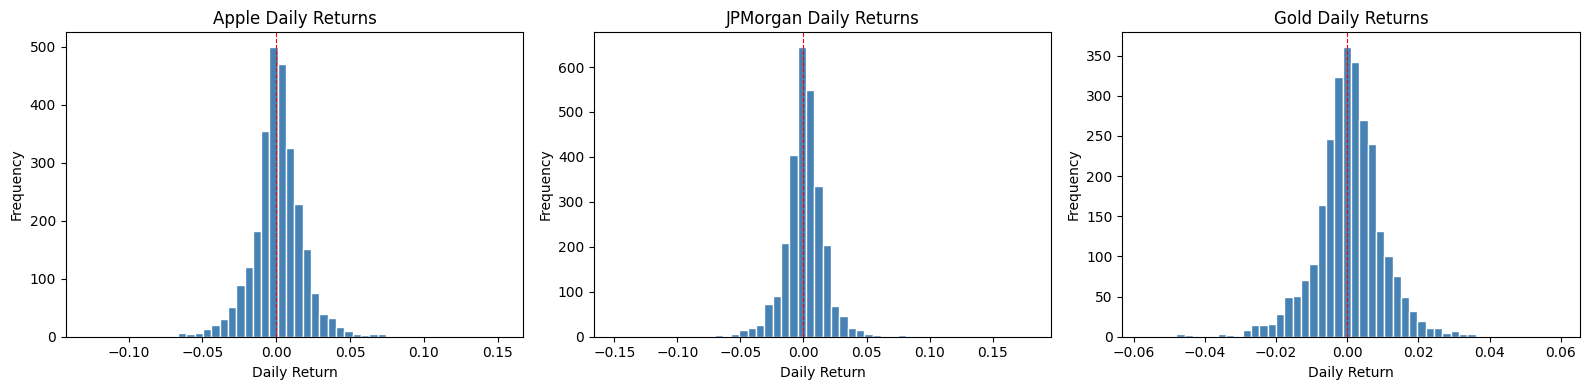

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(returns.columns):
    axes[i].hist(returns[col], bins=50, 
                 color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col} Daily Returns')
    axes[i].set_xlabel('Daily Return')
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(0, color='red', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()


In [10]:
# portfolio settings
portfolio_value = 100_000  # $100,000 total investment

weights = np.array([0.50, 0.30, 0.20])  # Apple, JPMorgan, Gold

# verify weights sum to 1
print(f'Weights sum to: {weights.sum()}')
print(f'\nPortfolio allocation:')
for name, w in zip(returns.columns, weights):
    print(f'  {name:>10} → {w*100:.0f}% → ${portfolio_value*w:,.0f}')

# calculate weighted portfolio returns
portfolio_returns = returns.dot(weights)

print(f'\nPortfolio daily returns shape: {portfolio_returns.shape}')
print(f'Average daily return: {portfolio_returns.mean():.4f}')
print(f'Daily volatility    : {portfolio_returns.std():.4f}')


Weights sum to: 1.0

Portfolio allocation:
       Apple → 50% → $50,000
    JPMorgan → 30% → $30,000
        Gold → 20% → $20,000

Portfolio daily returns shape: (2761,)
Average daily return: 0.0009
Daily volatility    : 0.0123


In [11]:
confidence_level = 0.95
significance     = 1 - confidence_level  # 0.05

# sort returns and find the 5th percentile
historical_var = np.percentile(portfolio_returns, 
                                significance * 100)

# convert to dollar loss
historical_var_dollar = portfolio_value * abs(historical_var)

print('=== Method 1: Historical VaR ===')
print(f'  Daily VaR (95%)    : {historical_var*100:.2f}%')
print(f'  Dollar VaR         : ${historical_var_dollar:,.0f}')
print(f'  Interpretation     : On 95% of days we will not')
print(f'                       lose more than ${historical_var_dollar:,.0f}')

=== Method 1: Historical VaR ===
  Daily VaR (95%)    : -1.73%
  Dollar VaR         : $1,731
  Interpretation     : On 95% of days we will not
                       lose more than $1,731


In [12]:
mean = portfolio_returns.mean()
std  = portfolio_returns.std()

# z-score for 95% confidence = 1.645
# this means 1.645 standard deviations below the mean
z_score = stats.norm.ppf(significance)

parametric_var = mean + z_score * std
parametric_var_dollar = portfolio_value * abs(parametric_var)

print('=== Method 2: Parametric VaR ===')
print(f'  Mean daily return  : {mean*100:.4f}%')
print(f'  Daily volatility   : {std*100:.4f}%')
print(f'  Z-score (95%)      : {z_score:.3f}')
print(f'  Daily VaR (95%)    : {parametric_var*100:.2f}%')
print(f'  Dollar VaR         : ${parametric_var_dollar:,.0f}')

=== Method 2: Parametric VaR ===
  Mean daily return  : 0.0879%
  Daily volatility   : 1.2299%
  Z-score (95%)      : -1.645
  Daily VaR (95%)    : -1.94%
  Dollar VaR         : $1,935


=== Method 3: Monte Carlo VaR ===
  Simulations        : 10,000
  Daily VaR (95%)    : -1.95%
  Dollar VaR         : $1,947


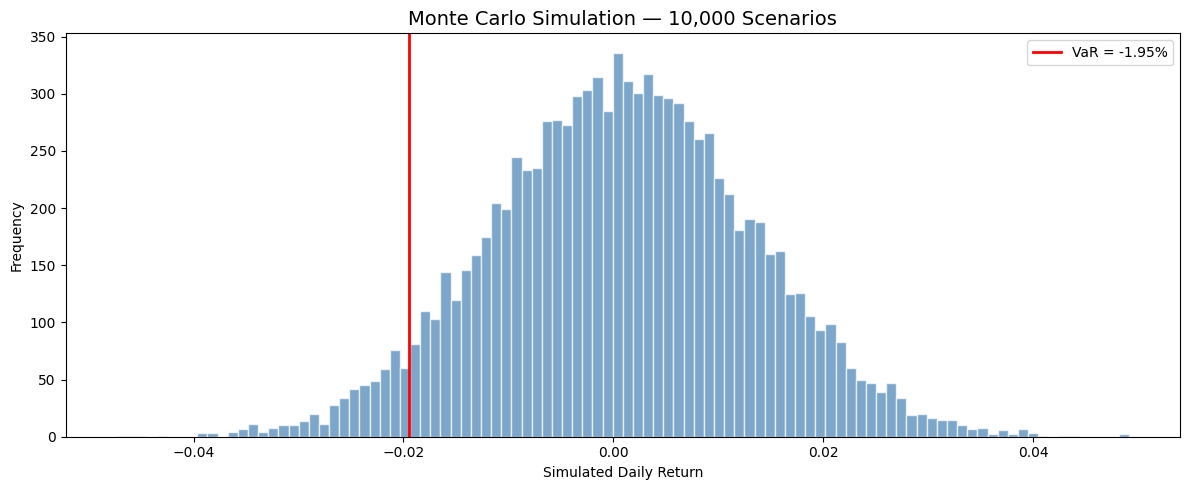

In [13]:
np.random.seed(42)
simulations = 10_000

# simulate 10,000 possible daily returns
# using the same mean and std as our real data
simulated_returns = np.random.normal(mean, std, simulations)

# calculate VaR from simulated returns
monte_carlo_var = np.percentile(simulated_returns, significance * 100)
monte_carlo_var_dollar = portfolio_value * abs(monte_carlo_var)

print('=== Method 3: Monte Carlo VaR ===')
print(f'  Simulations        : {simulations:,}')
print(f'  Daily VaR (95%)    : {monte_carlo_var*100:.2f}%')
print(f'  Dollar VaR         : ${monte_carlo_var_dollar:,.0f}')

# plot the simulation
plt.figure(figsize=(12, 5))
plt.hist(simulated_returns, bins=100, 
         color='steelblue', edgecolor='white', alpha=0.7)
plt.axvline(monte_carlo_var, color='red', 
            linewidth=2, label=f'VaR = {monte_carlo_var*100:.2f}%')
plt.title('Monte Carlo Simulation — 10,000 Scenarios', fontsize=14)
plt.xlabel('Simulated Daily Return')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
print('='*50)
print('   VALUE AT RISK COMPARISON — $100,000 Portfolio')
print('='*50)
print(f'  {"Method":<20} {"VaR %":<12} {"VaR $":<12}')
print('-'*50)
print(f'  {"Historical":<20} {historical_var*100:.2f}%      ${historical_var_dollar:,.0f}')
print(f'  {"Parametric":<20} {parametric_var*100:.2f}%      ${parametric_var_dollar:,.0f}')
print(f'  {"Monte Carlo":<20} {monte_carlo_var*100:.2f}%      ${monte_carlo_var_dollar:,.0f}')
print('='*50)
print(f'\n  Most conservative estimate : ${max(historical_var_dollar, parametric_var_dollar, monte_carlo_var_dollar):,.0f}')
print(f'  A bank would set aside     : ${max(historical_var_dollar, parametric_var_dollar, monte_carlo_var_dollar):,.0f} per day')
print('='*50)

   VALUE AT RISK COMPARISON — $100,000 Portfolio
  Method               VaR %        VaR $       
--------------------------------------------------
  Historical           -1.73%      $1,731
  Parametric           -1.94%      $1,935
  Monte Carlo          -1.95%      $1,947

  Most conservative estimate : $1,947
  A bank would set aside     : $1,947 per day


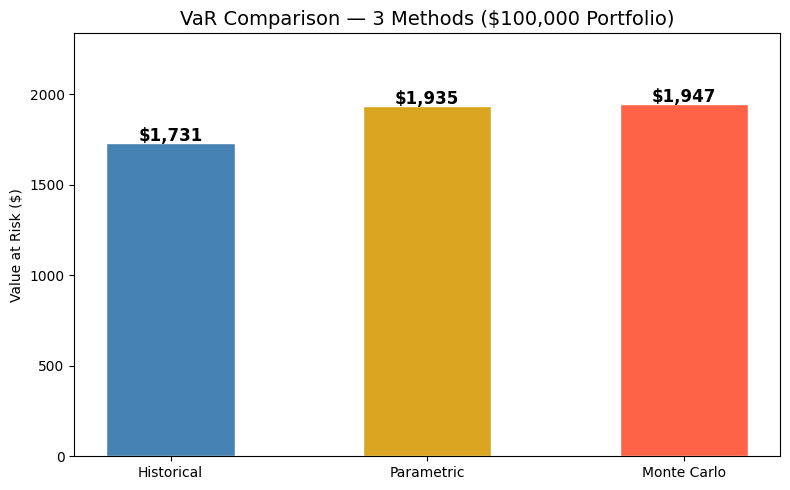

In [15]:
methods = ['Historical', 'Parametric', 'Monte Carlo']
values  = [historical_var_dollar, parametric_var_dollar, monte_carlo_var_dollar]
colors  = ['steelblue', 'goldenrod', 'tomato']

plt.figure(figsize=(8, 5))
bars = plt.bar(methods, values, color=colors, edgecolor='white', width=0.5)

# add value labels on top of each bar
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 10,
             f'${val:,.0f}', 
             ha='center', fontsize=12, fontweight='bold')

plt.title('VaR Comparison — 3 Methods ($100,000 Portfolio)', fontsize=14)
plt.ylabel('Value at Risk ($)')
plt.ylim(0, max(values) * 1.2)
plt.tight_layout()
plt.show()

In [16]:
def calculate_var(tickers_weights, portfolio_value=100_000, 
                  confidence=0.95, start='2015-01-01'):
    """
    tickers_weights: dict e.g. {'AAPL': 0.5, 'JPM': 0.3, 'GC=F': 0.2}
    """
    raw = {}
    for ticker, w in tickers_weights.items():
        data = yf.download(ticker, start=start, 
                          auto_adjust=True, progress=False)
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.droplevel(1)
        raw[ticker] = data['Close']
    
    prices  = pd.concat(raw, axis=1).dropna()
    returns = prices.pct_change().dropna()
    weights = np.array(list(tickers_weights.values()))
    
    port_returns = returns.dot(weights)
    significance = 1 - confidence
    
    hist_var   = abs(np.percentile(port_returns, significance*100))
    param_var  = abs(port_returns.mean() + 
                     stats.norm.ppf(significance) * port_returns.std())
    mc_returns = np.random.normal(port_returns.mean(), 
                                  port_returns.std(), 10_000)
    mc_var     = abs(np.percentile(mc_returns, significance*100))
    
    print(f'Portfolio Value : ${portfolio_value:,.0f}')
    print(f'Confidence      : {confidence*100:.0f}%')
    print(f'{"="*40}')
    print(f'Historical VaR  : ${hist_var*portfolio_value:,.0f}')
    print(f'Parametric VaR  : ${param_var*portfolio_value:,.0f}')
    print(f'Monte Carlo VaR : ${mc_var*portfolio_value:,.0f}')
    print(f'{"="*40}')
    print(f'Recommended     : ${max(hist_var, param_var, mc_var)*portfolio_value:,.0f}')

In [17]:
calculate_var({
    'AAPL' : 0.50,
    'JPM'  : 0.30,
    'GC=F' : 0.20
})

Portfolio Value : $100,000
Confidence      : 95%
Historical VaR  : $1,761
Parametric VaR  : $1,936
Monte Carlo VaR : $1,892
Recommended     : $1,936
